# Problem 5: Biased Coin Simulation

Simulating a biased coin (Bernoulli trial) where P[HEAD] = 0.70

Using only Python standard library and matplotlib.

In [1]:
import random
import matplotlib.pyplot as plt

In [2]:
# Set seed for reproducibility
random.seed(42)

# Probability of heads
P_HEAD = 0.70

In [3]:
def flip_coin(p_head=0.70):
    """Simulate a single biased coin flip.
    Returns 1 for heads, 0 for tails."""
    return 1 if random.random() < p_head else 0

def flip_coins(n_flips, p_head=0.70):
    """Simulate n_flips of a biased coin.
    Returns list of outcomes (1=head, 0=tail)."""
    return [flip_coin(p_head) for _ in range(n_flips)]

def count_heads(flips):
    """Count number of heads in a sequence of flips."""
    return sum(flips)

def longest_run_of_heads(flips):
    """Find the longest consecutive run of heads."""
    max_run = 0
    current_run = 0
    for flip in flips:
        if flip == 1:  # head
            current_run += 1
            if current_run > max_run:
                max_run = current_run
        else:
            current_run = 0
    return max_run

## Part (a): Single experiment with 50 trials

Count the number of heads in 50 trials and record the longest run of heads.

In [4]:
# Part (a): 50 coin flips
n_trials = 50
flips = flip_coins(n_trials, P_HEAD)

num_heads = count_heads(flips)
longest_run = longest_run_of_heads(flips)

print(f"Results of {n_trials} coin flips (P[HEAD] = {P_HEAD}):")
print(f"Number of heads: {num_heads}")
print(f"Number of tails: {n_trials - num_heads}")
print(f"Longest run of heads: {longest_run}")
print(f"\nExpected number of heads: {n_trials * P_HEAD}")
print(f"Observed proportion: {num_heads / n_trials:.2f}")

Results of 50 coin flips (P[HEAD] = 0.7):
Number of heads: 38
Number of tails: 12
Longest run of heads: 11

Expected number of heads: 35.0
Observed proportion: 0.76


In [5]:
# Show the sequence of flips
flip_str = ''.join(['H' if f == 1 else 'T' for f in flips])
print("Sequence of flips:")
print(flip_str)

Sequence of flips:
HHHHTHTHHHHHHHHHHHTHTHHHTHHHTHTTHTHHTHTHTHHHHHHHHH


## Part (b): Repeat the 50-flip experiment multiple times

Repeat the experiment 20, 100, 200, and 1000 times. Generate histograms showing the observed number of heads for each case.

In [6]:
def run_experiments(n_experiments, n_flips=50, p_head=0.70):
    """Run multiple experiments and return the number of heads in each."""
    head_counts = []
    for _ in range(n_experiments):
        flips = flip_coins(n_flips, p_head)
        head_counts.append(count_heads(flips))
    return head_counts

In [7]:
# Run experiments for different repetition counts
repetitions = [20, 100, 200, 1000]
results = {}

for n_exp in repetitions:
    results[n_exp] = run_experiments(n_exp, n_flips=50, p_head=P_HEAD)

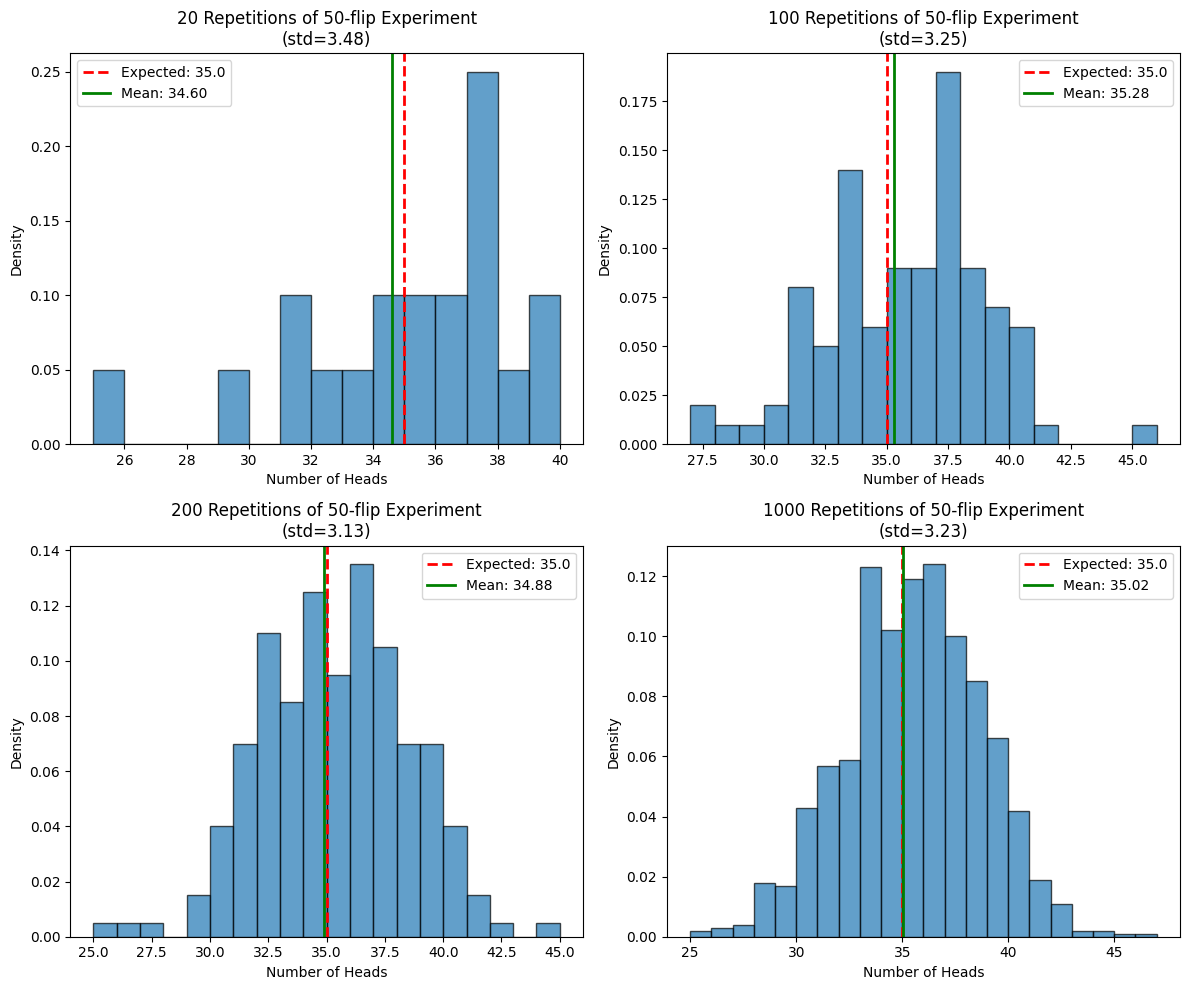

In [8]:
# Create histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

expected_heads = 50 * P_HEAD  # 35

for idx, n_exp in enumerate(repetitions):
    ax = axes[idx]
    data = results[n_exp]
    
    # Calculate statistics
    mean_heads = sum(data) / len(data)
    variance = sum((x - mean_heads)**2 for x in data) / len(data)
    std_dev = variance ** 0.5
    
    # Create histogram
    ax.hist(data, bins=range(min(data), max(data) + 2), 
            edgecolor='black', alpha=0.7, density=True)
    ax.axvline(x=expected_heads, color='red', linestyle='--', 
               linewidth=2, label=f'Expected: {expected_heads}')
    ax.axvline(x=mean_heads, color='green', linestyle='-', 
               linewidth=2, label=f'Mean: {mean_heads:.2f}')
    
    ax.set_xlabel('Number of Heads')
    ax.set_ylabel('Density')
    ax.set_title(f'{n_exp} Repetitions of 50-flip Experiment\n(std={std_dev:.2f})')
    ax.legend()

plt.tight_layout()
plt.savefig('problem5_part_b_histograms.png', dpi=150)
plt.show()

In [9]:
# Print summary statistics
print("Summary Statistics for Part (b):")
print("="*60)
print(f"Expected number of heads per experiment: {expected_heads}")
print(f"Expected proportion: {P_HEAD}")
print("\n")

for n_exp in repetitions:
    data = results[n_exp]
    mean_heads = sum(data) / len(data)
    variance = sum((x - mean_heads)**2 for x in data) / len(data)
    std_dev = variance ** 0.5
    min_val = min(data)
    max_val = max(data)
    
    print(f"N = {n_exp} repetitions:")
    print(f"  Mean: {mean_heads:.2f}")
    print(f"  Std Dev: {std_dev:.2f}")
    print(f"  Range: [{min_val}, {max_val}]")
    print()

Summary Statistics for Part (b):
Expected number of heads per experiment: 35.0
Expected proportion: 0.7


N = 20 repetitions:
  Mean: 34.60
  Std Dev: 3.48
  Range: [25, 39]

N = 100 repetitions:
  Mean: 35.28
  Std Dev: 3.25
  Range: [27, 45]

N = 200 repetitions:
  Mean: 34.88
  Std Dev: 3.13
  Range: [25, 44]

N = 1000 repetitions:
  Mean: 35.02
  Std Dev: 3.23
  Range: [25, 46]



### Comments on the Limit of the Histogram

As the number of repetitions increases, several observations emerge:

1. **Law of Large Numbers**: The sample mean converges to the expected value (35 heads). With more repetitions, the observed mean gets closer to 35.

2. **Central Limit Theorem**: The histogram approaches a normal distribution shape. For a binomial distribution with n=50 and p=0.70:
   - Expected value: E[X] = np = 50 * 0.70 = 35
   - Variance: Var(X) = np(1-p) = 50 * 0.70 * 0.30 = 10.5
   - Standard deviation: sqrt(10.5) = 3.24

3. **Shape Evolution**: With 20 repetitions, the histogram is rough and irregular. By 1000 repetitions, it clearly shows the bell-curve shape centered around 35.

4. **In the limit** (as repetitions approach infinity), the histogram converges to the binomial probability mass function B(50, 0.70), which is well-approximated by a normal distribution N(35, 10.5).

## Part (c): 500 coin tosses - Histogram of heads run lengths

Simulate tossing the coin 500 times and generate a histogram showing the heads run lengths.

In [10]:
def get_all_head_runs(flips):
    """Extract all runs of consecutive heads from a sequence.
    Returns a list of run lengths."""
    runs = []
    current_run = 0
    
    for flip in flips:
        if flip == 1:  # head
            current_run += 1
        else:
            if current_run > 0:
                runs.append(current_run)
            current_run = 0
    
    # Don't forget the last run if sequence ends with heads
    if current_run > 0:
        runs.append(current_run)
    
    return runs

In [11]:
# Part (c): 500 coin flips
n_flips_c = 500
flips_500 = flip_coins(n_flips_c, P_HEAD)

# Get all head runs
head_runs = get_all_head_runs(flips_500)

print(f"Results of {n_flips_c} coin flips:")
print(f"Total heads: {count_heads(flips_500)}")
print(f"Number of head runs: {len(head_runs)}")
print(f"Longest run: {max(head_runs) if head_runs else 0}")
print(f"Average run length: {sum(head_runs)/len(head_runs):.2f}" if head_runs else "N/A")

Results of 500 coin flips:
Total heads: 351
Number of head runs: 108
Longest run: 17
Average run length: 3.25


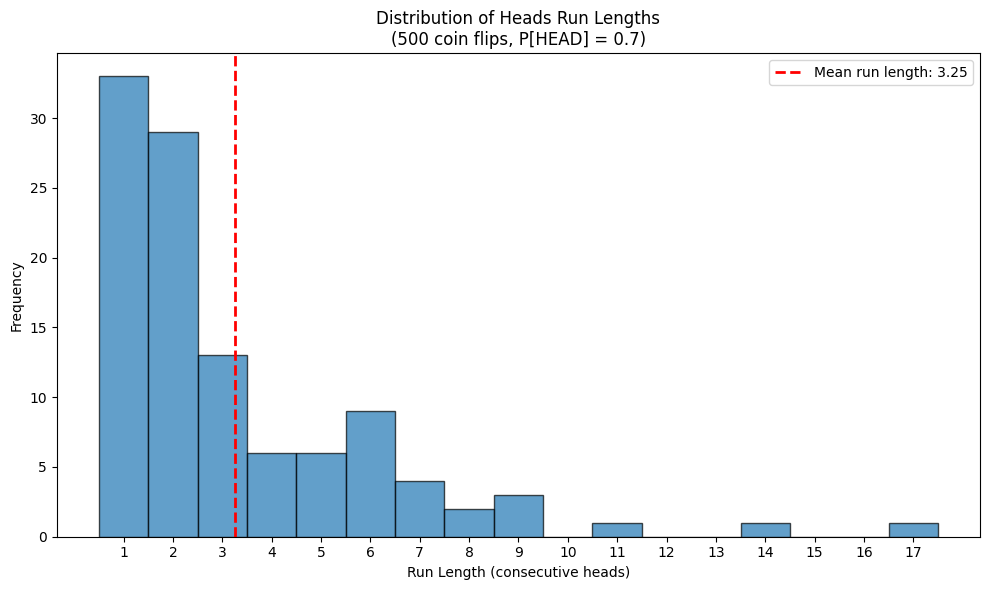

In [12]:
# Create histogram of head run lengths
plt.figure(figsize=(10, 6))

if head_runs:
    max_run = max(head_runs)
    bins = range(1, max_run + 2)
    
    plt.hist(head_runs, bins=bins, edgecolor='black', alpha=0.7, align='left')
    
    # Calculate mean run length
    mean_run = sum(head_runs) / len(head_runs)
    plt.axvline(x=mean_run, color='red', linestyle='--', 
                linewidth=2, label=f'Mean run length: {mean_run:.2f}')
    
    plt.xlabel('Run Length (consecutive heads)')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Heads Run Lengths\n(500 coin flips, P[HEAD] = {P_HEAD})')
    plt.legend()
    plt.xticks(range(1, max_run + 1))

plt.tight_layout()
plt.savefig('problem5_part_c_histogram.png', dpi=150)
plt.show()

In [13]:
# Detailed run length distribution
print("\nRun Length Distribution:")
print("="*40)

# Count occurrences of each run length
run_counts = {}
for run in head_runs:
    run_counts[run] = run_counts.get(run, 0) + 1

for length in sorted(run_counts.keys()):
    count = run_counts[length]
    proportion = count / len(head_runs)
    print(f"Run length {length:2d}: {count:3d} occurrences ({proportion*100:5.1f}%)")


Run Length Distribution:
Run length  1:  33 occurrences ( 30.6%)
Run length  2:  29 occurrences ( 26.9%)
Run length  3:  13 occurrences ( 12.0%)
Run length  4:   6 occurrences (  5.6%)
Run length  5:   6 occurrences (  5.6%)
Run length  6:   9 occurrences (  8.3%)
Run length  7:   4 occurrences (  3.7%)
Run length  8:   2 occurrences (  1.9%)
Run length  9:   3 occurrences (  2.8%)
Run length 11:   1 occurrences (  0.9%)
Run length 14:   1 occurrences (  0.9%)
Run length 17:   1 occurrences (  0.9%)


### Analysis of Run Lengths

The distribution of head run lengths follows a geometric-like distribution. This makes sense because:

1. **Run termination**: A run of heads ends when a tail appears (probability 0.30).

2. **Expected run length**: For a biased coin with P[HEAD] = p, the expected run length is approximately 1/(1-p) = 1/0.30 = 3.33 heads.

3. **Distribution shape**: Shorter runs are more common than longer runs. The probability of a run of exactly length k is approximately p^(k-1) * (1-p), which decreases exponentially with k.

4. **With p = 0.70**, longer runs are more likely compared to a fair coin, explaining why we see runs of 5+ heads relatively frequently.